# Referencial da IMU

Referencial local: Frente-Direita-Baixo\
Referencial global: Norte-Leste-Baixo

In [1]:
import numpy as np

aceleracoes_1 = np.load('dados_imu_teste_normalizados_1.npy')
print(f"Média Acelerações 1: {aceleracoes_1.mean(axis=0)}")

aceleracoes_2 = np.load('dados_imu_teste_normalizados_2.npy')
print(f"Média Acelerações 2: {aceleracoes_2.mean(axis=0)}")

aceleracoes_3 = np.load('dados_imu_teste_normalizados_3.npy')
print(f"Média Acelerações 3: {aceleracoes_3.mean(axis=0)}")

aceleracoes_4 = np.load('dados_imu_teste_normalizados_4.npy')
print(f"Média Acelerações 4: {aceleracoes_4.mean(axis=0)}")

media_aceleracoes = (aceleracoes_1.mean(axis=0) + aceleracoes_2.mean(axis=0) + aceleracoes_3.mean(axis=0) + aceleracoes_4.mean(axis=0)) / 4
print(f"\nMédia global das acelerações: {media_aceleracoes}")

media_aceleracoes_normalizada = media_aceleracoes / np.linalg.norm(media_aceleracoes)
print(f"Média global normalizada:   {media_aceleracoes_normalizada}")


Média Acelerações 1: [-0.12550811 -0.02397149  0.99180239]
Média Acelerações 2: [-0.12042242 -0.03014208  0.99226448]
Média Acelerações 3: [-0.10517897 -0.02573273  0.99411977]
Média Acelerações 4: [-0.1324282  -0.03150721  0.99069113]

Média global das acelerações: [-0.12088443 -0.02783838  0.99221944]
Média global normalizada:   [-0.12089123 -0.02783995  0.99227529]


## Determinação dos eixos

In [2]:
k = -1 * media_aceleracoes_normalizada
print(f"Vetor k:        [{k[0]:.4f}, {k[1]:.4f}, {k[2]:.4f}]")

g1 = aceleracoes_4.mean(axis=0)
g2 = np.load('dados_imu_teste_normalizados_inclinado.npy').mean(axis=0)

d = g1 - g2
j = np.cross(d, k)
j = j / np.linalg.norm(j)

print(f"Vetor j:        [{j[0]:.4f}, {j[1]:.4f}, {j[2]:.4f}]")

i = np.cross(j, k)
i = i / np.linalg.norm(i)
print(f"Vetor i:        [{i[0]:.4f}, {i[1]:.4f}, {i[2]:.4f}]")

Vetor k:        [0.1209, 0.0278, -0.9923]
Vetor j:        [0.0042, -0.9996, -0.0275]
Vetor i:        [0.9927, 0.0008, 0.1210]


# Tarefa 1:
Escreva a matriz Q de transformação de vetores no referencial da IMU para o referencial local do robô, como descrita pela equação (4.7), usando a convenção “Frente-Direita-Baixo”.

In [3]:
Q_FDB = np.vstack([i, j, k])
Q = Q_FDB
print(f"Matriz Q:\n[{Q_FDB[0][0]:.4f}, {Q_FDB[0][1]:.4f}, {Q_FDB[0][2]:.4f}]\n[{Q_FDB[1][0]:.4f}, {Q_FDB[1][1]:.4f}, {Q_FDB[1][2]:.4f}]\n[{Q_FDB[2][0]:.4f}, {Q_FDB[2][1]:.4f}, {Q_FDB[2][2]:.4f}]")

Matriz Q:
[0.9927, 0.0008, 0.1210]
[0.0042, -0.9996, -0.0275]
[0.1209, 0.0278, -0.9923]


# Tarefa 2:
Escreva a matriz usando a convençao “Frente-Esquerda-Cima”.

In [4]:
Q_FEC = np.vstack([i, -1*j, -1*k])
print(f"Matriz Q:\n[{Q_FEC[0][0]:.4f}, {Q_FEC[0][1]:.4f}, {Q_FEC[0][2]:.4f}]\n[{Q_FEC[1][0]:.4f}, {Q_FEC[1][1]:.4f}, {Q_FEC[1][2]:.4f}]\n[{Q_FEC[2][0]:.4f}, {Q_FEC[2][1]:.4f}, {Q_FEC[2][2]:.4f}]")

Matriz Q:
[0.9927, 0.0008, 0.1210]
[-0.0042, 0.9996, 0.0275]
[-0.1209, -0.0278, 0.9923]


# Calibração do Magnetômetro


## 1. Imports e configuração

In [5]:
import socket
import json
import urllib.request
from pathlib import Path

import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt


ENDERECO_IMU = "0.0.0.0"
PORTA_IMU = 1234

plt.rcParams["figure.figsize"] = (8, 6)

In [6]:
def le_dados_imu(N, func=None, endereco="localhost", porta=1234):
    dd = []
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.connect((endereco, porta))
        for i in range(N):
            data = s.recv(32)
            ax = int.from_bytes(data[0:2], byteorder='big', signed=True)
            ay = int.from_bytes(data[2:4], byteorder='big', signed=True)
            az = int.from_bytes(data[4:6], byteorder='big', signed=True)
            temp = int.from_bytes(data[6:8], byteorder='big', signed=True)
            wx = int.from_bytes(data[8:10], byteorder='big', signed=True)
            wy = int.from_bytes(data[10:12], byteorder='big', signed=True)
            wz = int.from_bytes(data[12:14], byteorder='big', signed=True)
            mx = int.from_bytes(data[14:16], byteorder='big', signed=True)
            my = int.from_bytes(data[16:18], byteorder='big', signed=True)
            mz = int.from_bytes(data[18:20], byteorder='big', signed=True)
            t = int.from_bytes(data[-8:], byteorder='little', signed=False)
            dd.append([ax, ay, az, wx, wy, wz, mx, my, mz, temp, t])
            if func:
                func(i)
    return dd


def coleta_magnetometro(n):
    """Lê n amostras e devolve só as colunas brutas do magnetômetro (n, 3)."""
    progresso = lambda i: print(f"Coletando: {int(100*(i+1)/n)}%", end="\r")
    bruto = le_dados_imu(n, func=progresso, endereco=ENDERECO_IMU, porta=PORTA_IMU)
    return np.array(bruto)[:, 6:9].astype(float)

## 2. Campo magnético local pelo WMM

Tenta obter latitude/longitude via `ip-api.com`; se falhar, usa POLI-USP (São Paulo).

In [7]:
import ahrs
try:
    with urllib.request.urlopen("http://ip-api.com/json/", timeout=5) as req:
        geodata = json.loads(req.read().decode())
    if geodata.get("status") != "success":
        raise RuntimeError(geodata)
    lat, lon, cidade = geodata["lat"], geodata["lon"], geodata["city"]
except Exception as e:
    print(f"ip-api falhou ({e}); usando POLI-USP")
    lat, lon, cidade = -23.5558, -46.7308, "São Paulo (POLI-USP)"
print(f"Local: {cidade} (lat={lat:.4f}, lon={lon:.4f})")

wmm = ahrs.utils.WMM()
wmm.magnetic_field(lat, lon)
F_wmm = float(wmm.F)  # módulo do campo local (mesma unidade que o WMM devolve)
H_wmm = float(wmm.H)
Z_wmm = float(wmm.Z)
I_wmm = float(wmm.I)
D_wmm = float(wmm.D)
print(f"F = {F_wmm:.2f}, H = {H_wmm:.2f}, Z = {Z_wmm:.2f} (unidades do WMM)")
print(f"Inclinação I = {I_wmm:.2f}°, Declinação D = {D_wmm:.2f}°")

Local: São Paulo (lat=-23.5475, lon=-46.6361)
F = 22793.31, H = 17258.81, Z = -14888.54 (unidades do WMM)
Inclinação I = -40.78°, Declinação D = -21.87°


## 3. Captura para calibração - 15.000 amostras



In [8]:
#captura = coleta_magnetometro(15000)
#np.savetxt("captura_magnetometro.txt", captura)
path1 = "./captura_magnetometro.txt"
captura = np.loadtxt(path1) #path1 is the path to the "captura_magnetometro.txt" that contains the magnetometer data

path2 = "./calibracao_magnetrometro_v2.npy"
captura2 = np.load(path2) #path2 is the path to the "calibracao_magnetrometro_v2.npy" that contains the magnetometer data 

captura  = np.concatenate([captura, captura2], axis=0)
print("\nFormato:", captura.shape)


Formato: (30000, 3)


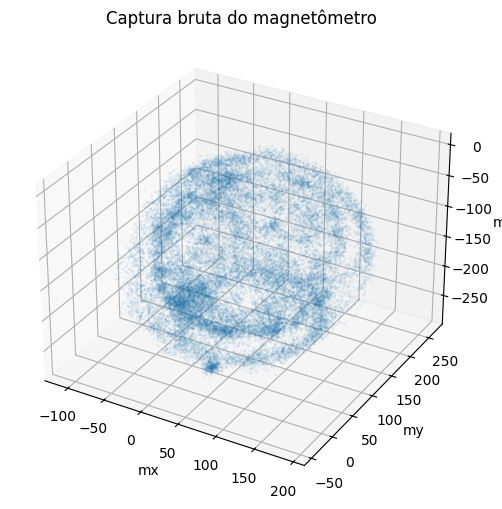

In [9]:
# Visualização 3D da nuvem de pontos brutos (deve parecer um elipsóide deslocado)
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(captura[:, 0], captura[:, 1], captura[:, 2], alpha=0.05, s=1)
ax.set_xlabel("mx"); ax.set_ylabel("my"); ax.set_zlabel("mz")
ax.set_title("Captura bruta do magnetômetro")
plt.show()

## 4. Função de custo e gradiente

Equação 4.13 com magnitude unitária (`f = 1`); a escala real é absorvida em S e corrigida no fim multiplicando por F.

In [10]:
F_UNITARIO = 1.0

def _monta_S_h(x):
    sxx, syy, szz, sxy, sxz, syz, hx, hy, hz = x
    S = np.array([[sxx, sxy, sxz], [sxy, syy, syz], [sxz, syz, szz]])
    h = np.array([hx, hy, hz])
    return S, h


def costfuncmag(x, data):
    S, h = _monta_S_h(x)
    U = (data - h) @ S  # S simétrica ⇒ S(l-h) por amostra
    R = np.linalg.norm(U, axis=1)
    return np.mean((R - F_UNITARIO) ** 2)


def grad_costfuncmag(x, data):
    sxx, syy, szz, sxy, sxz, syz, hx, hy, hz = x
    S, h = _monta_S_h(x)
    n = data.shape[0]

    diff = data - h
    U = diff @ S    #(n,3)
    R = np.linalg.norm(U, axis=1) #(n,1)
    R = np.where(R < 1e-12, 1e-12, R)
    coef = (2.0 / n) * (R - F_UNITARIO) / R

    g = np.zeros(9)
    g[0] = np.sum(coef * U[:, 0] * diff[:, 0])                                # ∂/∂sxx
    g[1] = np.sum(coef * U[:, 1] * diff[:, 1])                                # ∂/∂syy
    g[2] = np.sum(coef * U[:, 2] * diff[:, 2])                                # ∂/∂szz
    g[3] = np.sum(coef * (U[:, 0] * diff[:, 1] + U[:, 1] * diff[:, 0]))       # ∂/∂sxy
    g[4] = np.sum(coef * (U[:, 0] * diff[:, 2] + U[:, 2] * diff[:, 0]))       # ∂/∂sxz
    g[5] = np.sum(coef * (U[:, 1] * diff[:, 2] + U[:, 2] * diff[:, 1]))       # ∂/∂syz

    SU = U @ S  # ∂R/∂h_k = -SU[:,k] / R
    g[6] = -np.sum(coef * SU[:, 0])
    g[7] = -np.sum(coef * SU[:, 1])
    g[8] = -np.sum(coef * SU[:, 2])
    return g

In [11]:
# Verificação do gradiente por diferenças finitas
def diferencas_finitas(func, x, args=(), eps=1e-6):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for k in range(len(x)):
        passo = np.zeros_like(x); passo[k] = eps
        g[k] = (func(x + passo, *args) - func(x - passo, *args)) / (2 * eps)
    return g

x_teste = np.array([0.005, 0.005, 0.005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
g_ana = grad_costfuncmag(x_teste, captura)
g_num = diferencas_finitas(costfuncmag, x_teste, args=(captura,))
print("Diferença máx. analítico vs. numérico:", np.max(np.abs(g_ana - g_num)))

Diferença máx. analítico vs. numérico: 1.7639586218365366e-06


## 5. Otimização

Chute inicial: ganhos diagonais via amplitude em cada eixo (`sxx ≈ 2/(max−min)`), off-diagonais zero, `h` no centro do intervalo de cada eixo.

In [12]:
lmin = captura.min(axis=0)
lmax = captura.max(axis=0)
sxx0, syy0, szz0 = 2.0 / (lmax - lmin)
hx0, hy0, hz0 = (lmax + lmin) / 2.0
sol_inic = [sxx0, syy0, szz0, 0.0, 0.0, 0.0, hx0, hy0, hz0]
print("Chute inicial:", sol_inic)

cal_mag = scipy.optimize.minimize(
    costfuncmag, sol_inic, captura, jac=grad_costfuncmag
)
print(cal_mag)

Chute inicial: [np.float64(0.006622516556291391), np.float64(0.006472491909385114), np.float64(0.007220216606498195), 0.0, 0.0, 0.0, np.float64(41.0), np.float64(110.5), np.float64(-140.5)]
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.017420080695449966
        x: [ 8.126e-03  7.933e-03  8.161e-03  3.971e-05 -1.651e-04
            -4.664e-04  4.351e+01  1.142e+02 -1.391e+02]
      nit: 41
      jac: [-2.540e-07  7.593e-07  2.308e-06  3.725e-07  8.903e-07
             3.534e-06  9.946e-07 -5.756e-07 -2.705e-07]
 hess_inv: [[ 2.654e-04 -7.133e-05 ... -3.617e-01 -1.242e-01]
            [-7.133e-05  2.761e-04 ...  5.147e-01 -1.769e-01]
            ...
            [-3.617e-01  5.147e-01 ...  2.449e+04 -1.674e+03]
            [-1.242e-01 -1.769e-01 ... -1.674e+03  2.606e+04]]
     nfev: 55
     njev: 55


# Tarefa 3:

Escreva a matriz `S` usando os resultados da calibração.

In [13]:
S_unit, h = _monta_S_h(cal_mag.x)
S = F_wmm * S_unit

print("Resultados da calibracao do magnetometro")
print("-" * 44)
print("S_unit =")
print(S_unit)
print()
print("S = F_wmm * S_unit =")
print(S)
print()
print("h =")
print(h)

Resultados da calibracao do magnetometro
--------------------------------------------
S_unit =
[[ 8.12574803e-03  3.97102145e-05 -1.65092630e-04]
 [ 3.97102145e-05  7.93341724e-03 -4.66406342e-04]
 [-1.65092630e-04 -4.66406342e-04  8.16148061e-03]]

S = F_wmm * S_unit =
[[185.21272157   0.90512736  -3.76300805]
 [  0.90512736 180.82886565 -10.63094593]
 [ -3.76300805 -10.63094593 186.02718548]]

h =
[  43.51492531  114.18630907 -139.09982327]


# Tarefa 4:

Note que a correção `u = S(l - h)` obtém a medida do campo no referencial particular do magnetômetro. Escreva agora a matriz `S'` que obtém a medida no referencial dos sensores inerciais. Vide a Figura 4.14 para entender a diferença de convenção de eixos.

In [14]:
_monta_S_h(cal_mag.x)[0] * F_wmm

array([[185.21272157,   0.90512736,  -3.76300805],
       [  0.90512736, 180.82886565, -10.63094593],
       [ -3.76300805, -10.63094593, 186.02718548]])

In [15]:
# Montagem fisica informada:
# X_mag aponta para a esquerda, Y_mag para a frente e Z_mag para baixo.
# Portanto, em FDB: [frente, direita, baixo] = [my, -mx, mz].
R_mag_to_imu = np.array([
    [ 0, 1, 0],
    [1, 0, 0],
    [ 0, 0, -1],
])

S_prime = R_mag_to_imu @ S

print("Mudanca de referencial magnetometro -> IMU")
print("-" * 48)
print("R_mag_to_imu =")
print(R_mag_to_imu)
print()
print("S' = R_mag_to_imu @ S =")
print(S_prime)

Mudanca de referencial magnetometro -> IMU
------------------------------------------------
R_mag_to_imu =
[[ 0  1  0]
 [ 1  0  0]
 [ 0  0 -1]]

S' = R_mag_to_imu @ S =
[[   0.90512736  180.82886565  -10.63094593]
 [ 185.21272157    0.90512736   -3.76300805]
 [   3.76300805   10.63094593 -186.02718548]]


# Tarefa 5:

Escreva finalmente a matriz `W = QS'`, onde `Q` é a matriz obtida ao final da seção 4.2.3. Use a convenção “Frente-Direita-Baixo”. Note que a transformação `u = W(l - h)` transforma uma medida `l` em uma medida do campo no referencial local do robô.

In [16]:
# Q_path = "Q_FED.npy"
# Q = np.load(Q_path)
W = Q @ S_prime

erro_ortogonalidade = np.linalg.norm(Q.T @ Q - np.eye(3))
det_Q = np.linalg.det(Q)

print("Matriz de nivelamento e matriz final")
print("-" * 42)
# print(f"Arquivo de Q: {Q_path}")
print(f"det(Q): {det_Q:.6f}")
print(f"Erro de ortogonalidade de Q: {erro_ortogonalidade:.3e}")
print()
print("Q =")
print(Q)
print()
print("W = Q @ S' =")
print(W)

Matriz de nivelamento e matriz final
------------------------------------------
det(Q): 1.000000
Erro de ortogonalidade de Q: 2.228e-16

Q =
[[ 9.92657038e-01  7.99896213e-04  1.20960183e-01]
 [ 4.16124223e-03 -9.99612074e-01 -2.75388179e-02]
 [ 1.20891232e-01  2.78399461e-02 -9.92275288e-01]]

W = Q @ S' =
[[   1.50180615  180.78769126  -33.05777578]
 [-185.240735     -0.44506721    8.84027913]
 [   1.53179425   11.33699803  183.20022899]]


# Tarefa 6:

Com o robo parado e distante de anomalias ferromagneticas (atencao para moveis com metal!), colete 200 leituras do campo magnetico e determine sua media. Corrija-as e converta-as para o referencial local do robo. Compare os parametros `F`, `H`, `Z`, `I` e `D` com os obtidos pelo WMM.

In [17]:
try:
    with urllib.request.urlopen("http://ip-api.com/json/", timeout=5) as req:
        geodata = json.loads(req.read().decode())
    if geodata.get("status") != "success":
        raise RuntimeError(geodata)
    lat, lon, cidade = geodata["lat"], geodata["lon"], geodata["city"]
except Exception as e:
    print(f"ip-api falhou ({e}); usando POLI-USP")
    lat, lon, cidade = -23.5558, -46.7308, "Sao Paulo (POLI-USP)"

wmm = ahrs.utils.WMM()
wmm.magnetic_field(lat, lon)

F_wmm = float(wmm.F)
H_wmm = float(wmm.H)
Z_wmm = float(wmm.Z)
I_wmm = float(wmm.I)
D_wmm = float(wmm.D)

# Use a captura salva para reprodutibilidade. Para coletar novamente, use:
# validacao = coleta_magnetometro(200)
validacao = np.load("dados_magnetometro_200_v2.npy")

l_medio = validacao.mean(axis=0)
u_fdb_nivelado = W @ (l_medio - h)

X_meas, Y_meas, Z_meas = u_fdb_nivelado
F_meas = float(np.linalg.norm(u_fdb_nivelado))
H_meas = float(np.linalg.norm(u_fdb_nivelado[:2]))
Z_meas = float(Z_meas)

# Convencao NED/FDB: inclinacao positiva quando o campo aponta para baixo.
I_meas = float(np.degrees(np.arctan2(Z_meas, H_meas)))

# Esta comparacao de D com o WMM assume Frente=Norte e Direita=Leste.
# Se o robo estava com yaw diferente, D_meas fica deslocado pelo rumo do robo.
D_meas = float(np.degrees(np.arctan2(Y_meas, X_meas)))

def erro_angular_graus(medido, referencia):
    return (medido - referencia + 180.0) % 360.0 - 180.0

print("Validacao com 200 amostras")
print("-" * 36)
print(f"Local WMM: {cidade} (lat={lat:.4f}, lon={lon:.4f})")
print()
print(f"Media bruta l_medio: {l_medio}")
print(f"Campo corrigido u:   {u_fdb_nivelado}")
print()
print("Modulo e componentes")
print("Parametro        medido          WMM      erro rel.")
for nome, medido, referencia in [("F", F_meas, F_wmm), ("H", H_meas, H_wmm), ("Z", Z_meas, Z_wmm)]:
    erro = (medido - referencia) / referencia * 100 if referencia != 0 else float("nan")
    print(f"{nome:>3}       {medido:12.3f} {referencia:12.3f} {erro:+10.2f}%")

print()
print("Angulos")
print("Parametro        medido          WMM      erro abs.")
for nome, medido, referencia in [("I", I_meas, I_wmm), ("D", D_meas, D_wmm)]:
    erro = erro_angular_graus(medido, referencia)
    print(f"{nome:>3}       {medido:12.3f} {referencia:12.3f} {erro:+10.2f} deg")

print()
print("Obs.: a comparacao de D assume que Frente esta alinhado ao Norte e Direita ao Leste.")

Validacao com 200 amostras
------------------------------------
Local WMM: São Paulo (lat=-23.5475, lon=-46.6361)

Media bruta l_medio: [  99.735   80.575 -239.295]
Campo corrigido u:   [ -2679.84962653 -11285.04199432 -18650.7130792 ]

Modulo e componentes
Parametro        medido          WMM      erro rel.
  F          21963.216    22793.313      -3.64%
  H          11598.869    17258.808     -32.79%
  Z         -18650.713   -14888.542     +25.27%

Angulos
Parametro        medido          WMM      erro abs.
  I            -58.123      -40.783     -17.34 deg
  D           -103.359      -21.873     -81.49 deg

Obs.: a comparacao de D assume que Frente esta alinhado ao Norte e Direita ao Leste.


# Diagnostico

Verifique se `|S_unit @ (l - h)|` fica proximo de `1` tanto na captura de calibracao quanto nas amostras de validacao. Se a validacao cair fora da distribuicao da calibracao, a cobertura de orientacoes ou o ambiente magnetico da validacao provavelmente esta diferente.

Magnitude calibrada unitaria
---------------------------------
Calibracao: media = 0.9826, std = 0.1308, min = 0.5774, max = 1.3548
Validacao:  media = 0.9646, std = 0.0336, min = 0.8806, max = 1.0759

Leitura esperada: as duas distribuicoes devem ficar concentradas perto de 1.


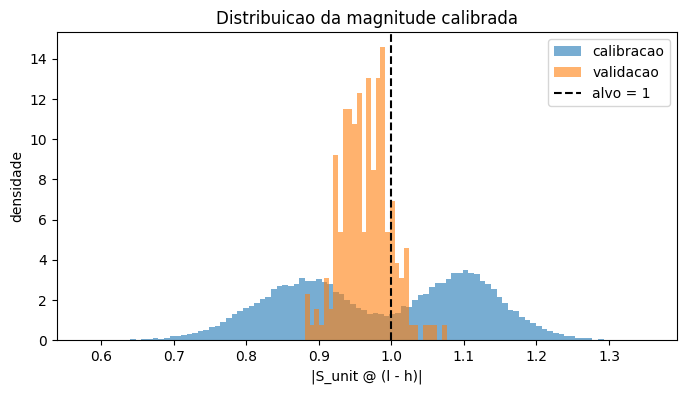

In [18]:
if "validacao" not in globals():
    validacao = np.load("dados_magnetometro_200_v2.npy")

S_unit_diag, h_diag = _monta_S_h(cal_mag.x)
mag_cal = np.linalg.norm((captura - h_diag) @ S_unit_diag.T, axis=1)
mag_val = np.linalg.norm((validacao - h_diag) @ S_unit_diag.T, axis=1)

print("Magnitude calibrada unitaria")
print("-" * 33)
print(f"Calibracao: media = {mag_cal.mean():.4f}, std = {mag_cal.std():.4f}, min = {mag_cal.min():.4f}, max = {mag_cal.max():.4f}")
print(f"Validacao:  media = {mag_val.mean():.4f}, std = {mag_val.std():.4f}, min = {mag_val.min():.4f}, max = {mag_val.max():.4f}")
print()
print("Leitura esperada: as duas distribuicoes devem ficar concentradas perto de 1.")

plt.figure(figsize=(8, 4))
plt.hist(mag_cal, bins=100, alpha=0.6, label="calibracao", density=True)
plt.hist(mag_val, bins=30, alpha=0.6, label="validacao", density=True)
plt.axvline(1.0, color="k", linestyle="--", label="alvo = 1")
plt.legend()
plt.xlabel("|S_unit @ (l - h)|")
plt.ylabel("densidade")
plt.title("Distribuicao da magnitude calibrada")
plt.show()

# Diagnostico

Compare o modulo `|u_robot|` com `F_wmm`. Como o modulo do campo e invariante por rotacao, esta e a comparacao direta mais segura durante a captura de calibracao. Durante giros do robo, `H` e `Z` no referencial local podem mudar amostra a amostra.

Erro de magnitude em relacao ao WMM
---------------------------------------
F_wmm = 22793.31 nT

Calibracao (15.000 amostras):
  |u_robot| media =   22396.25 nT   (-1.74% vs WMM)
  erro absoluto:   media =  -397.06 nT, std = 2982.06 nT
  erro |.|:         media = 2636.67 nT

Validacao (200 amostras):
  |u_robot| media =   21987.35 nT   (-3.54% vs WMM)
  erro absoluto:   media =  -805.96 nT, std = 764.97 nT
  erro |.|:         media = 924.70 nT


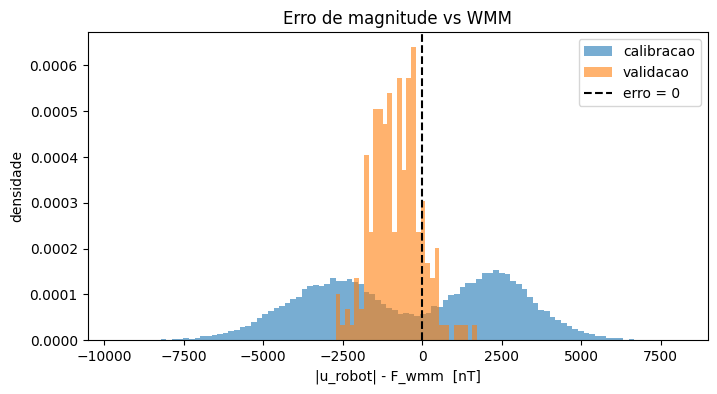

In [19]:
u_cal = (captura - h) @ W.T
u_val = (validacao - h) @ W.T

F_cal = np.linalg.norm(u_cal, axis=1)
F_val = np.linalg.norm(u_val, axis=1)

err_cal = F_cal - F_wmm
err_val = F_val - F_wmm

print("Erro de magnitude em relacao ao WMM")
print("-" * 39)
print(f"F_wmm = {F_wmm:.2f} nT")
print()
print("Calibracao (15.000 amostras):")
print(f"  |u_robot| media = {F_cal.mean():10.2f} nT   ({(F_cal.mean() / F_wmm - 1.0) * 100:+.2f}% vs WMM)")
print(f"  erro absoluto:   media = {err_cal.mean():+8.2f} nT, std = {err_cal.std():.2f} nT")
print(f"  erro |.|:         media = {np.abs(err_cal).mean():.2f} nT")
print()
print("Validacao (200 amostras):")
print(f"  |u_robot| media = {F_val.mean():10.2f} nT   ({(F_val.mean() / F_wmm - 1.0) * 100:+.2f}% vs WMM)")
print(f"  erro absoluto:   media = {err_val.mean():+8.2f} nT, std = {err_val.std():.2f} nT")
print(f"  erro |.|:         media = {np.abs(err_val).mean():.2f} nT")

plt.figure(figsize=(8, 4))
plt.hist(err_cal, bins=100, alpha=0.6, label="calibracao", density=True)
plt.hist(err_val, bins=30, alpha=0.6, label="validacao", density=True)
plt.axvline(0.0, color="k", linestyle="--", label="erro = 0")
plt.legend()
plt.xlabel("|u_robot| - F_wmm  [nT]")
plt.ylabel("densidade")
plt.title("Erro de magnitude vs WMM")
plt.show()

# Diagnostico

Use `magnetometro_bruto.npy` como validacao alternativa para uma rotacao aproximadamente pura em yaw. Se o robo ficou nivelado, `Z` deve ficar aproximadamente constante e perto de `Z_wmm`; `H` deve ficar perto de `H_wmm`; e `F` deve ficar perto de `F_wmm`.

Diagnostico com magnetometro_bruto.npy
------------------------------------------
shape = (15000, 3)
std por eixo bruto = [63.11 72.41  6.4 ]
Leitura esperada: z bruto com std menor sugere rotacao dominante em yaw.

Validacao em magnetometro_bruto.npy (15000 amostras):
               media        std       WMM         erro rel.
  F:     22481.18   1348.09    22793.31    -1.37%
  H:     19338.56   1297.35    17258.81   +12.05%
  Z:    -11395.32   1305.49   -14888.54   -23.46%


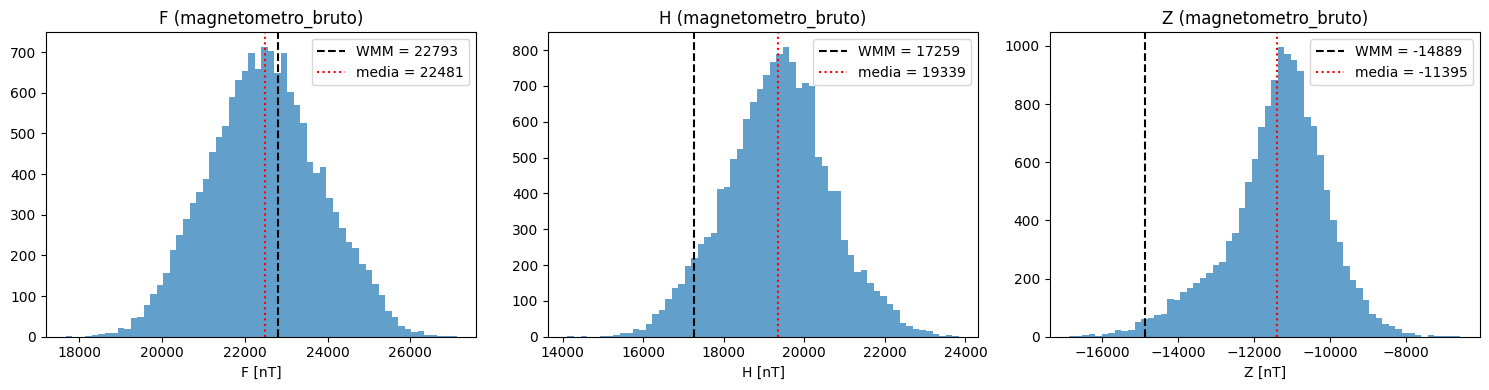

In [20]:
bruto = np.load("magnetometro_bruto.npy")

print("Diagnostico com magnetometro_bruto.npy")
print("-" * 42)
print(f"shape = {bruto.shape}")
print(f"std por eixo bruto = {bruto.std(axis=0).round(2)}")
print("Leitura esperada: z bruto com std menor sugere rotacao dominante em yaw.")

u_b = (bruto - h) @ W.T
F_b = np.linalg.norm(u_b, axis=1)
H_b = np.linalg.norm(u_b[:, :2], axis=1)
Z_b = u_b[:, 2]

print()
print(f"Validacao em magnetometro_bruto.npy ({len(bruto)} amostras):")
print("               media        std       WMM         erro rel.")
for nome, valores, referencia in [("F", F_b, F_wmm), ("H", H_b, H_wmm), ("Z", Z_b, Z_wmm)]:
    erro = (valores.mean() - referencia) / referencia * 100 if referencia != 0 else float("nan")
    print(f"  {nome}:   {valores.mean():10.2f}  {valores.std():8.2f}  {referencia:10.2f}  {erro:+7.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, valores, referencia, nome in zip(axes, [F_b, H_b, Z_b], [F_wmm, H_wmm, Z_wmm], ["F", "H", "Z"]):
    ax.hist(valores, bins=60, alpha=0.7)
    ax.axvline(referencia, color="k", linestyle="--", label=f"WMM = {referencia:.0f}")
    ax.axvline(valores.mean(), color="r", linestyle=":", label=f"media = {valores.mean():.0f}")
    ax.set_xlabel(f"{nome} [nT]")
    ax.set_title(f"{nome} (magnetometro_bruto)")
    ax.legend()
plt.tight_layout()
plt.show()

# Estimando a orientação do robô

# Tarefa 7:
Reproduza a Figura 4.19 com os seus proprios dados.

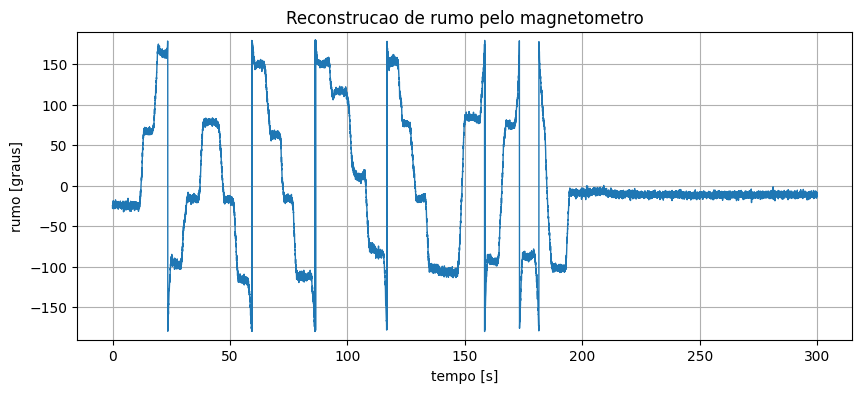

Figura 4.19 - reconstrucao de rumo
------------------------------------------
Amostras: 15000
Frequencia assumida: 50.0 Hz
Duracao: 299.98 s
Rumo minimo: -179.85 graus
Rumo maximo: 179.76 graus


In [21]:
FS_MAG = 50.0
DT_MAG = 1.0 / FS_MAG

magnetometro_bruto = np.load("magnetometro_bruto.npy")
tempo_mag = np.arange(magnetometro_bruto.shape[0]) * DT_MAG

campo_local = (W @ (magnetometro_bruto - h).T).T
phi = np.arctan2(campo_local[:, 1], campo_local[:, 0])
rumo_rad = (np.deg2rad(D_wmm) - phi + np.pi) % (2.0 * np.pi) - np.pi
rumo_deg = np.rad2deg(rumo_rad)

plt.figure(figsize=(10, 4))
plt.plot(tempo_mag, rumo_deg, linewidth=1.0)
plt.xlabel("tempo [s]")
plt.ylabel("rumo [graus]")
plt.title("Reconstrucao de rumo pelo magnetometro")
plt.grid(True)
plt.ylim(-190, 190)
plt.show()

print("Figura 4.19 - reconstrucao de rumo")
print("-" * 42)
print(f"Amostras: {magnetometro_bruto.shape[0]}")
print(f"Frequencia assumida: {FS_MAG:.1f} Hz")
print(f"Duracao: {tempo_mag[-1]:.2f} s")
print(f"Rumo minimo: {rumo_deg.min():.2f} graus")
print(f"Rumo maximo: {rumo_deg.max():.2f} graus")

# Tarefa 8:
Calcule o desvio padrao da estimativa do rumo, em graus, durante os 30 segundos finais da captura.

In [22]:
n_final = int(30.0 * FS_MAG)
rumo_final_rad = np.unwrap(rumo_rad[-n_final:])
desvio_final_deg = float(np.rad2deg(np.std(rumo_final_rad)))

tempo_inicio_final = tempo_mag[-n_final]
tempo_fim_final = tempo_mag[-1]

print("Desvio padrao do rumo nos 30 s finais")
print("-" * 44)
print(f"Intervalo analisado: {tempo_inicio_final:.2f} s a {tempo_fim_final:.2f} s")
print(f"Numero de amostras: {n_final}")
print(f"Desvio padrao: {desvio_final_deg:.2f} graus")

Desvio padrao do rumo nos 30 s finais
--------------------------------------------
Intervalo analisado: 270.00 s a 299.98 s
Numero de amostras: 1500
Desvio padrao: 2.18 graus


# Tarefa 9:
Complete a funcao `processa_dados` da classe `Bussola` no arquivo `rumo.py`. Use o codigo da secao anterior como exemplo. Note aqui que a estimativa de rumo deve ser dada em radianos.

In [23]:
from pathlib import Path
import importlib.util

rumo_path = Path("pmr3502-servico-rumo/rumo.py")
spec = importlib.util.spec_from_file_location("rumo_servico", rumo_path)
rumo_servico = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rumo_servico)

amostra_teste = magnetometro_bruto[0]
rumo_teste = rumo_servico.rumo_por_magnetometro(*amostra_teste)

previsoes = []
bussola_teste = rumo_servico.Bussola(lambda *args: previsoes.append(args), t0=0, rumo0=0, incerteza0=0)
bussola_teste.processa_dados(0, *amostra_teste)

tempo_cb, angulo_cb, sigma_cb, omega_cb = previsoes[-1]

print("Teste da classe Bussola")
print("-" * 28)
print(f"Arquivo atualizado: {rumo_path}")
print(f"Amostra bruta de teste: {amostra_teste}")
print(f"Rumo pela funcao auxiliar: {rumo_teste:.6f} rad = {np.rad2deg(rumo_teste):.2f} graus")
print(f"Callback gerado: tempo={tempo_cb:.3f} s, angulo={angulo_cb:.6f} rad, sigma={sigma_cb}, omega={omega_cb}")

Teste da classe Bussola
----------------------------
Arquivo atualizado: pmr3502-servico-rumo\rumo.py
Amostra bruta de teste: [  35.  209. -205.]
Rumo pela funcao auxiliar: -0.432306 rad = -24.77 graus
Callback gerado: tempo=0.000 s, angulo=-0.432306 rad, sigma=0, omega=0


# Tarefa 10:
Execute o servico e observe o comportamento do rumo. Experimente agora aproximar pequenos objetos de ferro do sensor MPU9250 e observe seu efeito na estimativa de rumo.

In [24]:
print("Execucao do servico de rumo")
print("-" * 32)
print("Dentro da pasta pmr3502-servico-rumo, execute:")
print("python servico_rumo.py -f bussola")
print()
print("Depois, abra no navegador:")
print("http://<nome-do-robo>:8087")
print()
print("Observacao esperada:")
print("aproximar objetos ferromagneticos do MPU9250 altera o campo medido")
print("e causa erro/deslocamento perceptivel na estimativa de rumo.")

Execucao do servico de rumo
--------------------------------
Dentro da pasta pmr3502-servico-rumo, execute:
python servico_rumo.py -f bussola

Depois, abra no navegador:
http://<nome-do-robo>:8087

Observacao esperada:
aproximar objetos ferromagneticos do MPU9250 altera o campo medido
e causa erro/deslocamento perceptivel na estimativa de rumo.


# Tarefa 11:
Implemente um filtro passa-baixa com frequencia de corte igual a `1/3 Hz` para processar a captura da secao 4.5. Lembre-se no calculo de `alpha` que a frequencia de captura naquele caso foi de `50 Hz`.

In [25]:
def normaliza_angulo_rad(angulo):
    return (angulo + np.pi) % (2.0 * np.pi) - np.pi


def filtro_passa_baixa_angular(x, fc, fs):
    alpha = np.exp(-2.0 * np.pi * fc / fs)
    y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        diferenca = normaliza_angulo_rad(x[i] - y[i - 1])
        y[i] = normaliza_angulo_rad(y[i - 1] + (1.0 - alpha) * diferenca)
    return y, alpha

FC_OFFLINE = 1.0 / 3.0
rumo_filtrado_rad, alpha_50hz = filtro_passa_baixa_angular(rumo_rad, fc=FC_OFFLINE, fs=FS_MAG)
rumo_filtrado_deg = np.rad2deg(rumo_filtrado_rad)

print("Filtro passa-baixa offline")
print("-" * 31)
print(f"fc: {FC_OFFLINE:.6f} Hz")
print(f"fs: {FS_MAG:.1f} Hz")
print(f"alpha: {alpha_50hz:.6f}")

Filtro passa-baixa offline
-------------------------------
fc: 0.333333 Hz
fs: 50.0 Hz
alpha: 0.958977


# Tarefa 12:
Reproduza a imagem da Figura 4.19 agora com o sinal filtrado. O que acontece neste caso quando o rumo do robo ultrapassa os `180 graus`?

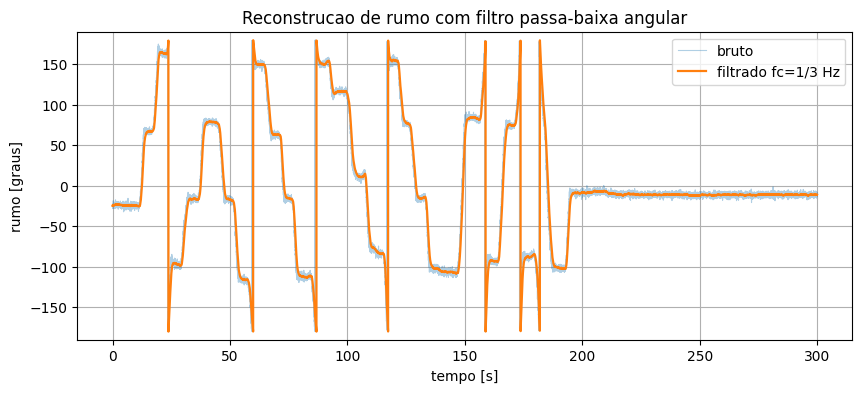

Rumo bruto versus filtrado
------------------------------
Desvio padrao bruto nos 30 s finais:    2.18 graus
Desvio padrao filtrado nos 30 s finais: 0.34 graus

Quando o rumo ultrapassa 180 graus, a representacao com arctan2 salta para -180 graus.
O filtro trata a diferenca angular normalizada, entao a filtragem segue pelo menor caminho angular.


In [26]:
desvio_final_filtrado_deg = float(np.rad2deg(np.std(np.unwrap(rumo_filtrado_rad[-n_final:]))))

plt.figure(figsize=(10, 4))
plt.plot(tempo_mag, rumo_deg, label="bruto", alpha=0.35, linewidth=0.8)
plt.plot(tempo_mag, rumo_filtrado_deg, label="filtrado fc=1/3 Hz", linewidth=1.6)
plt.xlabel("tempo [s]")
plt.ylabel("rumo [graus]")
plt.title("Reconstrucao de rumo com filtro passa-baixa angular")
plt.grid(True)
plt.ylim(-190, 190)
plt.legend()
plt.show()

print("Rumo bruto versus filtrado")
print("-" * 30)
print(f"Desvio padrao bruto nos 30 s finais:    {desvio_final_deg:.2f} graus")
print(f"Desvio padrao filtrado nos 30 s finais: {desvio_final_filtrado_deg:.2f} graus")
print()
print("Quando o rumo ultrapassa 180 graus, a representacao com arctan2 salta para -180 graus.")
print("O filtro trata a diferenca angular normalizada, entao a filtragem segue pelo menor caminho angular.")

# Tarefa 13:
Implemente um filtro passa-baixa com frequencia de corte `1/4 Hz` na funcao `processa_dados`. Lembre-se que agora a frequencia de amostragem e de `20 Hz`.

In [27]:
FC_ONLINE = 0.25
FS_ONLINE = 20.0
alpha_20hz = np.exp(-2.0 * np.pi * FC_ONLINE / FS_ONLINE)

previsoes_filtradas = []
bussola_filtrada_teste = rumo_servico.BussolaFiltrada(
    lambda *args: previsoes_filtradas.append(args),
    t0=0,
    rumo0=0,
    incerteza0=0,
)

for k, amostra in enumerate(magnetometro_bruto[:10]):
    t_ns = int(k * (1.0 / FS_ONLINE) * 1e9)
    bussola_filtrada_teste.processa_dados(t_ns, *amostra)

print("Filtro online no servico")
print("-" * 28)
print(f"fc: {FC_ONLINE:.3f} Hz")
print(f"fs: {FS_ONLINE:.1f} Hz")
print(f"alpha esperado: {alpha_20hz:.6f}")
print(f"alpha implementado: {bussola_filtrada_teste._alpha:.6f}")
print(f"Ultima previsao filtrada: {previsoes_filtradas[-1][1]:.6f} rad")
print()
print("Para executar a versao filtrada no robo:")
print("python servico_rumo.py -f bussola_filtrada")

Filtro online no servico
----------------------------
fc: 0.250 Hz
fs: 20.0 Hz
alpha esperado: 0.924465
alpha implementado: 0.924465
Ultima previsao filtrada: -0.433734 rad

Para executar a versao filtrada no robo:
python servico_rumo.py -f bussola_filtrada


# Tarefa 14:
Observe o que acontece no aplicativo interativo quando voce movimenta rapidamente o robo.

In [28]:
print("Observacao do aplicativo com bussola_filtrada")
print("-" * 45)
print("Ao movimentar rapidamente o robo, o rumo exibido fica mais suave,")
print("mas passa a responder com atraso por causa do filtro passa-baixa.")
print("Quanto menor a frequencia de corte, maior a suavizacao e maior o atraso.")

Observacao do aplicativo com bussola_filtrada
---------------------------------------------
Ao movimentar rapidamente o robo, o rumo exibido fica mais suave,
mas passa a responder com atraso por causa do filtro passa-baixa.
Quanto menor a frequencia de corte, maior a suavizacao e maior o atraso.
